### 라이브러리 불러오기

In [1]:
import pandas as pd

### pandas 자료구조 이해하기
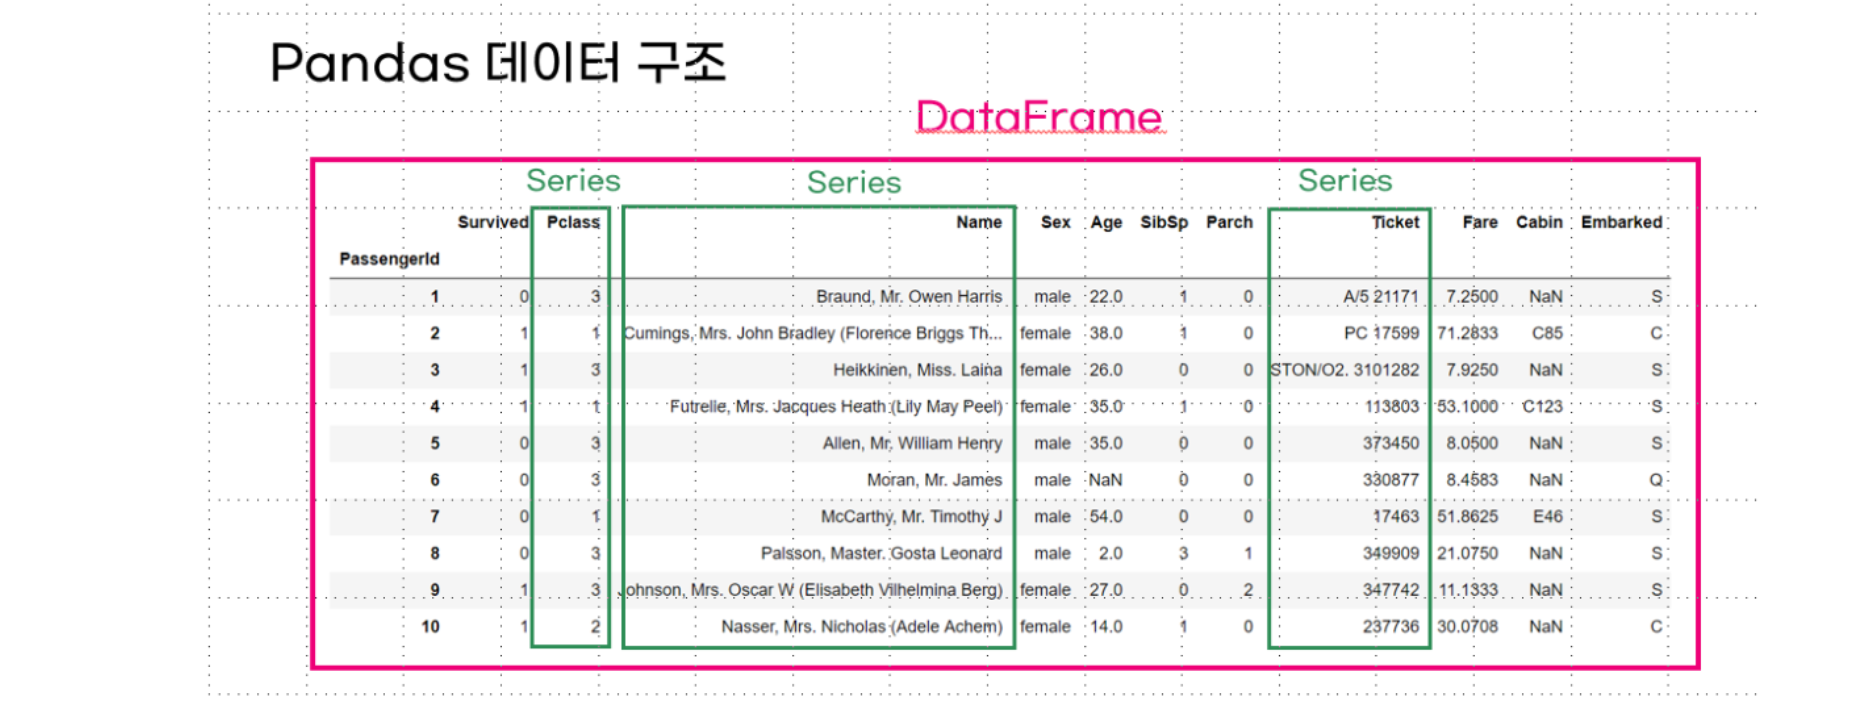
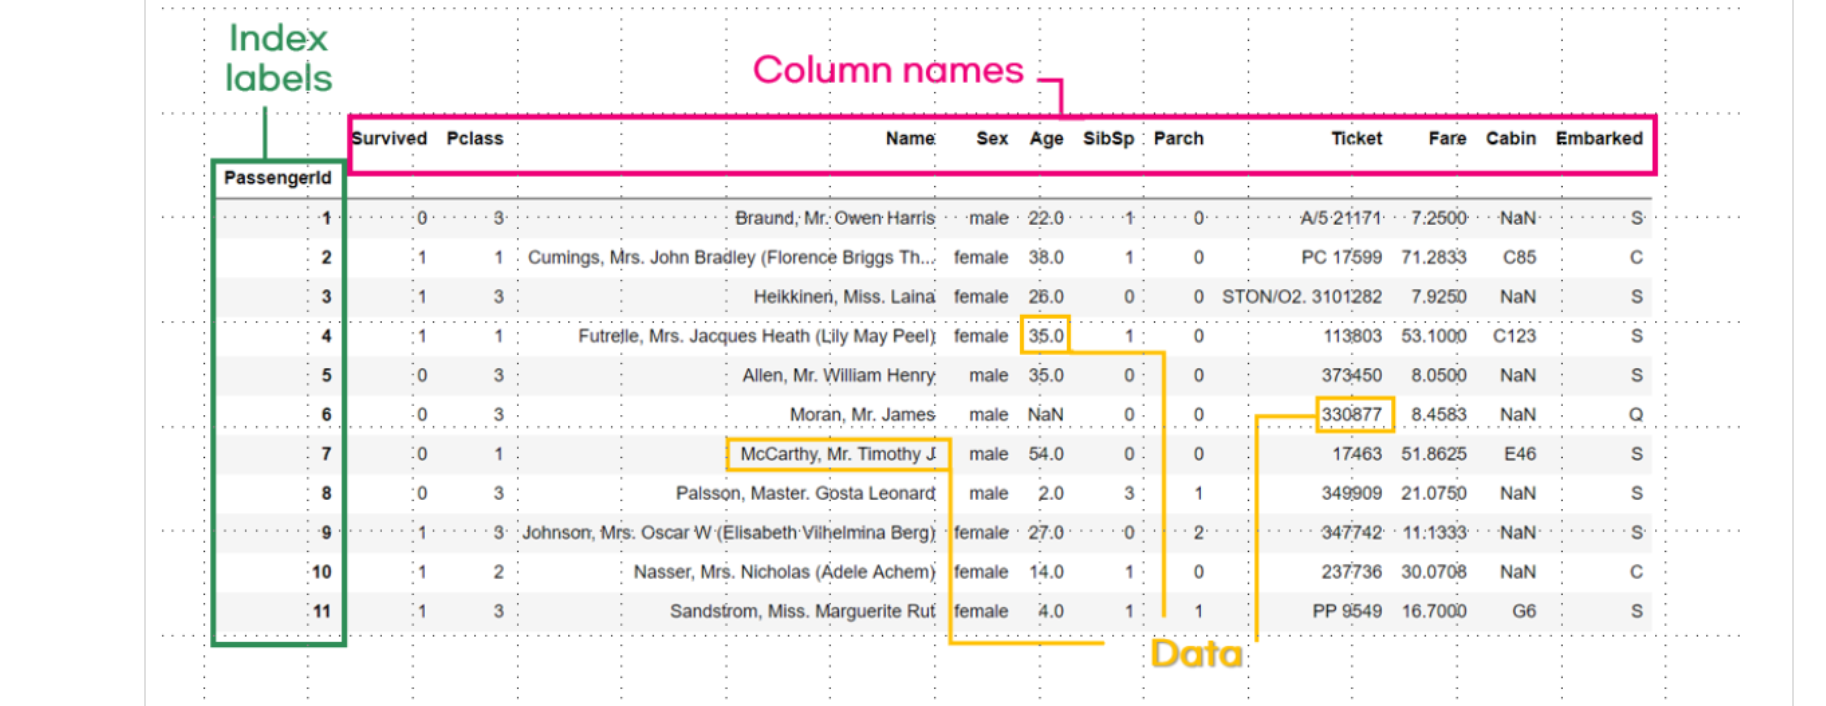

In [ ]:
#series 1차원 - 인덱스 값
#dataframe 2차원 -표와 같은 형태

### 1. series 생성 및 이름 지정


In [3]:
s1 = pd.Series([10,20,30], name = "점수")
s1

0    10
1    20
2    30
Name: 점수, dtype: int64

In [9]:
# DataFrame 생성
# 딕셔너리 기반
df = pd.DataFrame({'이름' : ['영희', '철수', '민수'], 
                   '나이' : [ 20, 21, 19],
                  '성별' : ['F', 'M', 'M']})
df

#리스트 기반
df2 = pd.DataFrame([["영희",20,"F"],
                   ["철수",21,"M"],
                   ["민수",19,"M"]],
                   columns=['이름','나이','성별'])
df2

,이름,나이,성별
0,영희,20,F
1,철수,21,M
2,민수,19,M


### 3. series 병합해서 dataframe 생성하기

In [13]:
s2 = pd.Series(["영희", "철수", "민수"], name="이름")
print(s1)
print(s2)

0    10
1    20
2    30
Name: 점수, dtype: int64
0    영희
1    철수
2    민수
Name: 이름, dtype: object


In [24]:
#s1과 s2 병합
#병합하는 함수 -> concat()
df3 = pd.concat([s2, s1], axis=1)
df3

,이름,점수
0,영희,10
1,철수,20
2,민수,30


### 4. 데이터 접근
- 데이터 인덱싱, 슬라이싱
   - 위치기반 접근
   - 조건기반 접근

In [25]:
df

,이름,나이,성별
0,영희,20,F
1,철수,21,M
2,민수,19,M


In [34]:
#행 슬라이싱을 통해 0번 행을 출력
display(df[0:1])
display(df[1:])

,이름,나이,성별
0,영희,20,F


,이름,나이,성별
1,철수,21,M
2,민수,19,M


In [40]:
#인덱서를 활용한 행 접근(loc, iloc)
display(df.loc[0])
display(df.loc[1:])
display(df.loc[1:2])
display(df.iloc[1:2]) #loc와 차이는 인덱스 번호로 가지고오는 경우 끝번호 포함x

이름    영희
나이    20
성별     F
Name: 0, dtype: object

,이름,나이,성별
1,철수,21,M
2,민수,19,M


,이름,나이,성별
1,철수,21,M
2,민수,19,M


,이름,나이,성별
1,철수,21,M


In [46]:
#열접근
display(df["이름"])
display(df[["이름"]])
display(df[["이름", "성별"]])

0    영희
1    철수
2    민수
Name: 이름, dtype: object

,이름
0,영희
1,철수
2,민수


,이름,성별
0,영희,F
1,철수,M
2,민수,M


In [49]:
#열 접근 -> 인덱서 활용
display(df.loc[:, "이름"])
display(df.loc[:, ["이름"]])
display(df.loc[:, ["이름", "성별"]])

0    영희
1    철수
2    민수
Name: 이름, dtype: object

,이름
0,영희
1,철수
2,민수


,이름,성별
0,영희,F
1,철수,M
2,민수,M


In [52]:
display(df.loc[:1])
display(df.iloc[0:2, 0:])

,이름,나이,성별
0,영희,20,F
1,철수,21,M


,이름,나이,성별
0,영희,20,F
1,철수,21,M


In [58]:
df.loc[2, "이름"]


'민수'

In [60]:
#조건기반으로 데이터 가져오기
#성별이 M인 사람의 행만 가져오기
df[df["성별"]=="M"]

,이름,나이,성별
1,철수,21,M
2,민수,19,M


In [72]:
#나이가 20세 이상인 사람의 행만 가져오기
df[df["나이"] >= 20]

,이름,나이,성별
0,영희,20,F
1,철수,21,M


In [63]:
#나이가 20세 이상인 사람의 이름만 가져오기
df.loc[df["나이"] >= 20, "이름"]

0    영희
1    철수
Name: 이름, dtype: object

In [76]:
s1 = pd.Series([10, 20, 30], name="점수")
display(s1)
s2 = pd.Series(["영희", "철수", "민수"], name='이름')
s2
#s1, s2를 병합해보자!
#병합하는 함수는? -> concat() -> axis = 0 (아래로 붙는 형태), axis = 1 (옆으로 붙는 형태)
df3 = pd.concat([s1,s2], axis=1)
df3

0    10
1    20
2    30
Name: 점수, dtype: int64

,점수,이름
0,10,영희
1,20,철수
2,30,민수


In [89]:
# 🎈 연습- df3 데이터 접근하기
## 1. 점수가 15점 이상인 학생 정보 출력하기
display(df3[df3["점수"] >= 15])
## 2. 이름이 '철수'인 행만 출력하기
display(df3[df3["이름"] == "철수"])
## 3. 이름이 '철수'인 행의 점수만 출력하기
display(df3[df3["이름"] == "철수"]["점수"])
display(df3.loc[df3["이름"] == "철수", "점수"])
## 4. 불리언 조건을 연결하자!
## 점수가 20 이상이고 이름이 '민수'가 아닌 사람 출력하기
## 논리를 연결할때에는 불리언 인덱싱 진행시 비트연산자 연결(&, \) 
display(df3[(df3["점수"] >= 20) & (df3["이름"] != "민수")])


,점수,이름
1,20,철수
2,30,민수


,점수,이름
1,20,철수


1    20
Name: 점수, dtype: int64

1    20
Name: 점수, dtype: int64

,점수,이름
1,20,철수
